In [5]:
import re
import glob
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.tri as mtri
from pyproj import Transformer

import matplotlib.pyplot as plt

# ============================================================
# Read the contour points
# ============================================================

def read_contour(contour_file = "contour30sp.csv"):
    df = pd.read_csv(contour_file)

    ds = xr.Dataset(
        coords={
            "point": np.arange(len(df))
        },
        data_vars={
            "lon":      ("point", df["contour30s_lon"].to_numpy()),
            "lat":      ("point", df["contour30s_lat"].to_numpy()),
            "x":        ("point", df["contour30s_x"].to_numpy()),
            "y":        ("point", df["contour30s_y"].to_numpy()),
            "normal_x": ("point", df["normals30_x"].to_numpy()),
            "normal_y": ("point", df["normals30_y"].to_numpy()),
        }
    )
    # flip the sign because normals to the tangents point offshore
    ds["normal_x"] = -ds["normal_x"]
    ds["normal_y"] = -ds["normal_y"]
    return ds

contour_ds = read_contour()
contour_ds


# ============================================================
# 1. READ ADCIRC / SWAN .spc FILES
# ============================================================
_float_re = re.compile(r"[-+]?\d*\.\d+(?:[Ee][-+]?\d+)?|[-+]?\d+(?:[Ee][-+]?\d+)?")
_int_re   = re.compile(r"[-+]?\d+")
_time_re  = re.compile(r"^\d{8}\.\d{6}$")


def _floats_in_line(s):
    return [float(x) for x in _float_re.findall(s)]


def _ints_in_line(s):
    return [int(x) for x in _int_re.findall(s)]


def _parse_swan_time(tok):
    return datetime.strptime(tok, "%Y%m%d.%H%M%S")


def _read_number_block(lines, i0, n, kind="float"):
    vals = []
    i = i0
    getvals = _floats_in_line if kind == "float" else _ints_in_line
    while len(vals) < n:
        vals.extend(getvals(lines[i]))
        i += 1
    return np.array(vals[:n]), i


def read_swan_spec_vadens_factor(spc_path):
    """
    Read one SWAN .spc file and return:
      lon, lat, freqs, dirs, times, E(nt,nf,nd) in m^2/Hz/rad

    Notes
    -----
    dirs in the file are SWAN/CDIR directions, treated here as CARTESIAN and FROM.
    """
    lines = Path(spc_path).read_text(errors="ignore").splitlines()

    for i, ln in enumerate(lines):
        s = ln.strip()

        if s.startswith("LONLAT"):
            lon, lat = _floats_in_line(lines[i + 2])[:2]

        elif s.startswith("AFREQ"):
            nf = int(lines[i + 1].split()[0])
            freqs, _ = _read_number_block(lines, i + 2, nf, kind="float")
            freqs = freqs.astype(float)

        elif s.startswith("CDIR"):
            nd = int(lines[i + 1].split()[0])
            dirs, _ = _read_number_block(lines, i + 2, nd, kind="float")
            dirs = dirs.astype(float)

    times = []
    E_list = []

    i = 0
    while i < len(lines):
        tok = lines[i].strip().split()
        if tok and _time_re.match(tok[0]):
            t = _parse_swan_time(tok[0])

            while not lines[i].strip().startswith("FACTOR"):
                i += 1

            factor = _floats_in_line(lines[i + 1])[0]
            A, i = _read_number_block(lines, i + 2, nf * nd, kind="int")
            A = A.reshape(nf, nd)

            # convert from m^2/Hz/deg to m^2/Hz/rad
            E = factor * A * (180.0 / np.pi)

            times.append(t)
            E_list.append(E)
        else:
            i += 1

    E = np.stack(E_list, axis=0)   # (time, freq, dir)

    return {
        "lon": lon,
        "lat": lat,
        "freqs": freqs,
        "dirs": dirs,
        "times": times,
        "E": E,
    }


def bnd_index_1based(fp):
    return int(re.search(r"bnd(\d+)", Path(fp).stem).group(1))


def read_adcirc_2dspec(spec_files, contour_ds):
    """
    Read all bnd*.spc files into one aligned Dataset with dims:
      time, point, freq, dir
    """
    npts = contour_ds.sizes["point"]
    ds_list = [None] * npts

    for fp in spec_files:
        idx0 = bnd_index_1based(fp) - 1
        rec = read_swan_spec_vadens_factor(fp)

        dsi = xr.Dataset(
            coords={
                "time": np.asarray(rec["times"]),
                "point": [idx0],
                "freq": np.asarray(rec["freqs"]),
                "dir": np.asarray(rec["dirs"]),
            },
            data_vars={
                "spec": (
                    ("time", "point", "freq", "dir"),
                    rec["E"][:, np.newaxis, :, :]
                ),
            }
        )

        ds_list[idx0] = dsi

    ds = xr.concat(ds_list, dim="point")

    ds.attrs["model"] = "ADCIRC/SWAN"
    ds.attrs["dir_convention"] = "from"
    ds.attrs["dir_frame"] = "cartesian"
    ds.attrs["spec_units"] = "m^2/Hz/rad"

    ds = ds.assign_coords(
        lon=("point", contour_ds["lon"].values),
        lat=("point", contour_ds["lat"].values),
        x=("point", contour_ds["x"].values),
        y=("point", contour_ds["y"].values),
    )
    ds["normal_x"] = ("point", contour_ds["normal_x"].values)
    ds["normal_y"] = ("point", contour_ds["normal_y"].values)

    return ds


# ============================================================
# 2. DIRECTION HELPERS
# ============================================================
def wrap360(deg):
    return np.mod(deg, 360.0)


def cartesian_to_geographic_deg(theta_cart):
    """
    Cartesian CCW from +x(east) -> geographic CW from north
    """
    return wrap360(90.0 - np.asarray(theta_cart, float))


def az_to_xy_geo(az_deg):
    az = np.deg2rad(az_deg)
    return np.sin(az), np.cos(az)   # east, north


def circular_mean_deg(dir_deg, weights):
    ux, uy = az_to_xy_geo(dir_deg)
    x = np.sum(weights * ux, axis=-1)
    y = np.sum(weights * uy, axis=-1)
    return wrap360(np.degrees(np.arctan2(x, y)))


def circular_diff_deg(a, b):
    """
    signed shortest difference a - b in degrees
    """
    return (a - b + 180.0) % 360.0 - 180.0


def direction_binwidth_deg(dir_deg):
    """
    Bin width from circularly sorted centers.
    Assumes nearly uniform directional spacing.
    """
    d = np.sort(wrap360(np.asarray(dir_deg, float)))
    dd = np.diff(np.r_[d, d[0] + 360.0])
    return float(np.median(dd))


# ============================================================
# 3. SPECTRAL BULK STATS FROM ADCIRC/SWAN 2D SPECTRA
# ============================================================
def calc_adcirc_spec_stats(ds_ad):
    """
    Compute spectral bulk stats from ds_ad['spec'].

    Returns Dataset with:
      hm0_spec
      tp_spec
      dir_mean_from_spec
      dir_mean_to_spec
      dir_peak_from_spec
      dir_peak_to_spec
    """
    S = ds_ad["spec"].values                   # (time, point, freq, dir)
    f = ds_ad["freq"].values
    d_cart_from = ds_ad["dir"].values

    # ADCIRC/SWAN .spc directions: cartesian FROM
    d_geo_from = cartesian_to_geographic_deg(d_cart_from)
    d_geo_to = wrap360(d_geo_from + 180.0)

    dtheta = np.deg2rad(direction_binwidth_deg(d_cart_from))

    # 1D spectrum E(f) in m^2/Hz
    Ef = np.sum(S, axis=-1) * dtheta          # (time, point, freq)

    # m0, Hm0
    m0 = np.trapezoid(Ef, x=f, axis=-1)       # (time, point)
    hm0 = 4.0 * np.sqrt(m0)

    # Peak frequency / period from 1D spectrum
    ipk = np.argmax(Ef, axis=-1)              # (time, point)
    fp = f[ipk]
    tp = 1.0 / fp

    # Energy-weighted mean direction
    # integrate spectrum over frequency first: Sdir(dir) [m^2/rad]
    Sdir = np.trapezoid(S, x=f, axis=2)       # (time, point, dir)
    dir_mean_from = circular_mean_deg(d_geo_from[None, None, :], Sdir * dtheta)
    dir_mean_to = wrap360(dir_mean_from + 180.0)

    # Peak direction at peak frequency
    nt, npnt, nf, nd = S.shape
    dir_peak_from = np.full((nt, npnt), np.nan, dtype=float)

    for it in range(nt):
        for ip in range(npnt):
            jf = ipk[it, ip]
            jd = np.argmax(S[it, ip, jf, :])
            dir_peak_from[it, ip] = d_geo_from[jd]

    dir_peak_to = wrap360(dir_peak_from + 180.0)

    ds_out = xr.Dataset(
        coords={"time": ds_ad["time"], "point": ds_ad["point"]},
        data_vars={
            "m0_spec": (("time", "point"), m0.astype(np.float32)),
            "hm0_spec": (("time", "point"), hm0.astype(np.float32)),
            "tp_spec": (("time", "point"), tp.astype(np.float32)),
            "dir_mean_from_spec": (("time", "point"), dir_mean_from.astype(np.float32)),
            "dir_mean_to_spec": (("time", "point"), dir_mean_to.astype(np.float32)),
            "dir_peak_from_spec": (("time", "point"), dir_peak_from.astype(np.float32)),
            "dir_peak_to_spec": (("time", "point"), dir_peak_to.astype(np.float32)),
        }
    )

    ds_out["hm0_spec"].attrs["units"] = "m"
    ds_out["tp_spec"].attrs["units"] = "s"
    ds_out["dir_mean_to_spec"].attrs["units"] = "deg"
    ds_out["dir_peak_to_spec"].attrs["units"] = "deg"

    return ds_out


# ============================================================
# 4. INTERPOLATE WHOLE-MESH BULK ADCIRC OUTPUT TO CONTOUR
# ============================================================
def build_contour_barycentric_weights(ds_mesh, contour_ds, crs_out="EPSG:32617"):
    """
    Build triangle indices and barycentric weights for contour points
    using the ADCIRC mesh.
    """
    xp = contour_ds["x"].values
    yp = contour_ds["y"].values

    lon_all = ds_mesh["x"].values
    lat_all = ds_mesh["y"].values

    transformer = Transformer.from_crs("EPSG:4326", crs_out, always_xy=True)
    x_all, y_all = transformer.transform(lon_all, lat_all)

    triangles = ds_mesh["element"].values.astype(np.int64) - 1

    tri = mtri.Triangulation(x_all, y_all, triangles)
    trifinder = tri.get_trifinder()
    face_idx = trifinder(xp, yp)

    bad = np.where(face_idx < 0)[0]
    if bad.size:
        raise ValueError(f"{bad.size} contour points fall outside the mesh.")

    v = triangles[face_idx, :]   # (point, 3)

    x0 = x_all[v[:, 0]]; y0 = y_all[v[:, 0]]
    x1 = x_all[v[:, 1]]; y1 = y_all[v[:, 1]]
    x2 = x_all[v[:, 2]]; y2 = y_all[v[:, 2]]

    den = ((y1 - y2) * (x0 - x2) + (x2 - x1) * (y0 - y2))
    w0 = ((y1 - y2) * (xp - x2) + (x2 - x1) * (yp - y2)) / den
    w1 = ((y2 - y0) * (xp - x2) + (x0 - x2) * (yp - y2)) / den
    w2 = 1.0 - w0 - w1
    w = np.stack([w0, w1, w2], axis=1).astype(np.float32)

    idx_da = xr.DataArray(v, dims=("point", "corner"), coords={"point": contour_ds["point"], "corner": [0, 1, 2]})
    w_da = xr.DataArray(w, dims=("point", "corner"), coords={"point": contour_ds["point"], "corner": [0, 1, 2]})

    return idx_da, w_da


def first_data_var(ds):
    return list(ds.data_vars)[0]


def interp_mesh_var_to_contour(ds_var, idx_da, w_da, varname=None):
    """
    Interpolate one ADCIRC mesh variable (time,node) to contour points.
    """
    if varname is None:
        varname = first_data_var(ds_var)

    da = ds_var[varname]  # expected dims (time, node) or (node, time)
    if da.dims[0] != "time":
        da = da.transpose("time", ...)

    # gather triangle vertices
    da_tpc = da.isel(node=idx_da)   # (time, point, corner)
    da_tp = (da_tpc * w_da).sum("corner")

    return da_tp


# ============================================================
# 5. BUILD COMPARISON DATASET
# ============================================================
def build_adcirc_spec_vs_bulk_comparison(
    contour_ds,
    spec_dir,
    ds_Hs,
    ds_Dir,
    ds_Tps,
):
    # ---- read native 2D spectra ----
    spec_files = sorted(glob.glob(spec_dir + "bnd*.spc"))
    ds_ad = read_adcirc_2dspec(spec_files, contour_ds)

    # ---- compute spectral stats ----
    ds_spec = calc_adcirc_spec_stats(ds_ad)

    # ---- interpolate whole-mesh bulk stats to contour ----
    idx_da, w_da = build_contour_barycentric_weights(ds_Hs, contour_ds)

    hs_bulk = interp_mesh_var_to_contour(ds_Hs, idx_da, w_da, varname="swan_HS")
    tp_bulk = interp_mesh_var_to_contour(ds_Tps, idx_da, w_da, varname="swan_TPS")
    dir_bulk = interp_mesh_var_to_contour(ds_Dir, idx_da, w_da, varname="swan_DIR")

    # ---- align times ----
    ds_spec2, hs_bulk2, tp_bulk2, dir_bulk2 = xr.align(
        ds_spec, hs_bulk, tp_bulk, dir_bulk, join="inner"
    )

    ds_cmp = xr.Dataset(
        coords={"time": ds_spec2["time"], "point": ds_spec2["point"]},
        data_vars={
            "hm0_spec": ds_spec2["hm0_spec"],
            "tp_spec": ds_spec2["tp_spec"],
            "dir_mean_to_spec": ds_spec2["dir_mean_to_spec"],
            "dir_peak_to_spec": ds_spec2["dir_peak_to_spec"],
            "hs_bulk": hs_bulk2.astype(np.float32),
            "tp_bulk": tp_bulk2.astype(np.float32),
            "dir_bulk": dir_bulk2.astype(np.float32),
        }
    )

    ds_cmp["d_hm0"] = ds_cmp["hm0_spec"] - ds_cmp["hs_bulk"]
    ds_cmp["d_tp"] = ds_cmp["tp_spec"] - ds_cmp["tp_bulk"]

    # circular differences, works with dask-backed xarray objects
    ds_cmp["d_dir_mean"] = (ds_cmp["dir_mean_to_spec"] - ds_cmp["dir_bulk"] + 180.0) % 360.0 - 180.0
    ds_cmp["d_dir_peak"] = (ds_cmp["dir_peak_to_spec"] - ds_cmp["dir_bulk"] + 180.0) % 360.0 - 180.0

    return ds_ad, ds_spec, ds_cmp

    


# ============================================================
# 7. RUN
# ============================================================
# Example inputs:
# contour_ds  : your contour dataset with point, x, y, lon, lat, normal_x, normal_y
data_dir    = "F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/bulk_wave_stats/"
spec_dir    = "F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/spec_files/"

fname_Hs    = "allnodes_sig_waveheight_ts_swan_HS_63_copy.nc"
Dir_fname   = "allnodes_direction_ts_swan_DIR_63_copy.nc"
Tps_fname   = "allnodes_TPSperiod_ts_swan_TPS_63_copy.nc"

ds_Hs  = xr.open_dataset(data_dir + fname_Hs, chunks={"time": 8})
ds_Dir = xr.open_dataset(data_dir + Dir_fname, chunks={"time": 8})
ds_Tps = xr.open_dataset(data_dir + Tps_fname, chunks={"time": 8})

ds_ad, ds_spec, ds_cmp = build_adcirc_spec_vs_bulk_comparison(
    contour_ds=contour_ds,
    spec_dir=spec_dir,
    ds_Hs=ds_Hs,
    ds_Dir=ds_Dir,
    ds_Tps=ds_Tps,
)

stats = summary_stats(ds_cmp)
print(stats)
print(ds_cmp)

{'hm0': {'bias': -0.0010855341097339988, 'rmse': 0.001783839426934719, 'corr': 0.9999999253919578, 'n': 61200}, 'tp': {'bias': -0.030485229566693306, 'rmse': 0.45872753858566284, 'corr': 0.9919132347414705, 'n': 61200}, 'dir_mean_to_vs_bulk': {'mean_diff_deg': -11.415470123291016, 'rms_diff_deg': 83.89710235595703, 'mad_deg': 60.15432357788086, 'n': 61200}, 'dir_peak_to_vs_bulk': {'mean_diff_deg': 9.191445350646973, 'rms_diff_deg': 76.61749267578125, 'mad_deg': 57.76687240600586, 'n': 61200}}
<xarray.Dataset> Size: 3MB
Dimensions:           (time: 144, point: 425)
Coordinates:
  * time              (time) datetime64[ns] 1kB 2024-09-25 ... 2024-09-27T23:...
  * point             (point) int64 3kB 0 1 2 3 4 5 ... 419 420 421 422 423 424
    lon               (point) float64 3kB -88.0 -87.98 -87.96 ... -82.44 -82.44
    lat               (point) float64 3kB 29.96 29.96 29.96 ... 25.54 25.52
    x                 (point) float64 3kB -1.759e+05 -1.739e+05 ... 3.557e+05
    y                

In [16]:
ds_cmp

<xarray.Dataset> Size: 3MB
Dimensions:           (time: 144, point: 425)
Coordinates:
  * time              (time) datetime64[ns] 1kB 2024-09-25 ... 2024-09-27T23:...
  * point             (point) int64 3kB 0 1 2 3 4 5 ... 419 420 421 422 423 424
    lon               (point) float64 3kB -88.0 -87.98 -87.96 ... -82.44 -82.44
    lat               (point) float64 3kB 29.96 29.96 29.96 ... 25.54 25.52
    x                 (point) float64 3kB -1.759e+05 -1.739e+05 ... 3.557e+05
    y                 (point) float64 3kB 3.335e+06 3.335e+06 ... 2.824e+06
Data variables:
    hm0_spec          (time, point) float32 245kB 0.3185 0.3167 ... 2.205 2.2
    tp_spec           (time, point) float32 245kB 3.235 3.235 ... 9.234 9.234
    dir_mean_to_spec  (time, point) float32 245kB 122.9 123.0 ... 275.9 276.0
    dir_peak_to_spec  (time, point) float32 245kB 135.0 135.0 ... 305.0 305.0
    hs_bulk           (time, point) float32 245kB dask.array<chunksize=(7, 425), meta=np.ndarray>
    tp_bulk           (time, point) float32 245kB dask.array<chunksize=(7, 425), meta=np.ndarray>
    dir_bulk          (time, point) float32 245kB dask.array<chunksize=(7, 425), meta=np.ndarray>
    d_hm0             (time, point) float32 245kB dask.array<chunksize=(7, 425), meta=np.ndarray>
    d_tp              (time, point) float32 245kB dask.array<chunksize=(7, 425), meta=np.ndarray>
    d_dir_mean        (time, point) float32 245kB dask.array<chunksize=(7, 425), meta=np.ndarray>
    d_dir_peak        (time, point) float32 245kB dask.array<chunksize=(7, 425), meta=np.ndarray>

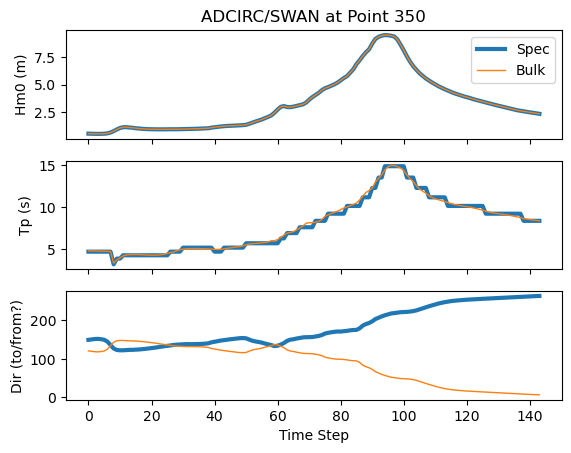

In [19]:
# Plot 

icp = 350
fig, ax = plt.subplots( 3, 1, sharex = True )
ax[0].plot( ds_cmp['hm0_spec'].values[:,icp],'-', lw=3, label='Spec')
ax[0].plot( ds_cmp['hs_bulk'].values[:,icp],'-', lw=1, label='Bulk')
ax[0].set_ylabel('Hm0 (m)')
ax[1].plot( ds_cmp['tp_spec'].values[:,icp],'-', lw=3, label='Spec')
ax[1].plot( ds_cmp['tp_bulk'].values[:,icp],'-', lw=1, label='Bulk')
ax[1].set_ylabel('Tp (s)')
ax[2].plot( ds_cmp['dir_mean_to_spec'].values[:,icp],'-', lw=3, label='Spec')
ax[2].plot( ds_cmp['dir_bulk'].values[:,icp],'-', lw=1, label='Bulk')
ax[2].set_ylabel('Dir (to/from?)')
ax[2].set_xlabel('Time Step')
ts = f'ADCIRC/SWAN at Point {icp}'
ax[0].set_title(ts)
ax[0].legend()